<a href="https://colab.research.google.com/github/nharri64/ECGR-4105/blob/Homeworks-and-datasets/Noah_Harris_801353171_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [ ]:
uploaded = files.upload()

Saving Cancer.csv to Cancer.csv


In [ ]:
def train_model(X_train, X_test, y_train, y_test,
                title, penalty=None, alpha=0.0001):

    model = SGDClassifier(
        loss='log_loss',
        penalty=penalty,
        alpha=alpha,
        learning_rate='constant',
        eta0=0.01,
        random_state=42,
        shuffle=True
    )

    epochs = 300

    train_loss = []
    test_loss = []
    train_accuracy = []
    test_accuracy = []

    for i in range(epochs):

        # Train for one epoch
        model.partial_fit(
            X_train,
            y_train,
            classes=np.array([0, 1])
        )

        # Predictions and probabilities
        train_prob = model.predict_proba(X_train)
        test_prob = model.predict_proba(X_test)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        # Record losses
        train_loss.append(
            log_loss(y_train, train_prob, labels=[0, 1])
        )

        test_loss.append(
            log_loss(y_test, test_prob, labels=[0, 1])
        )

        # Record accuracy
        train_accuracy.append(
            accuracy_score(y_train, train_pred)
        )

        test_accuracy.append(
            accuracy_score(y_test, test_pred)
        )

    # Final results
    predictions = model.predict(X_test)

    results = {
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(
            y_test, predictions, zero_division=0
        ),
        'Recall': recall_score(
            y_test, predictions, zero_division=0
        ),
        'F1 Score': f1_score(
            y_test, predictions, zero_division=0
        )
    }

    print("\n", title)
    print("-" * 45)

    for name, value in results.items():
        print(f"{name}: {value:.4f}")

    print("Final Training Loss:", round(train_loss[-1], 4))
    print("Final Evaluation Loss:", round(test_loss[-1], 4))

    # GRAPH 1 - LOSS
    plt.figure(figsize=(8, 5))

    plt.plot(train_loss, label='Training Loss')
    plt.plot(test_loss, label='Evaluation Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Binary Cross-Entropy Loss')
    plt.title(title + ' - Loss')
    plt.legend()
    plt.grid()
    plt.show()

    # GRAPH 2 - ACCURACY
    plt.figure(figsize=(8, 5))

    plt.plot(train_accuracy, label='Training Accuracy')
    plt.plot(test_accuracy, label='Evaluation Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(title + ' - Classification Accuracy')
    plt.legend()
    plt.grid()
    plt.show()

    # GRAPH 3 - CONFUSION MATRIX
    cm = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1]
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Negative (0)', 'Positive (1)']
    ).plot(cmap='Blues')

    plt.title(title + ' - Confusion Matrix')
    plt.show()

    return model, results

# Problem 1 - Diabetes Logistic Regression

In [ ]:
diabetes = pd.read_csv('/content/diabetes.csv')

X_d = diabetes.drop(columns=['Outcome'])
y_d = diabetes['Outcome'].astype(int)

print("Dataset shape:", diabetes.shape)
print("Input features:", X_d.shape[1])

# 80/20 split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d,
    y_d,
    test_size=0.20,
    random_state=42,
    stratify=y_d
)

# Standardization
scaler_d = StandardScaler()

X_train_d = scaler_d.fit_transform(X_train_d)
X_test_d = scaler_d.transform(X_test_d)

print("Training samples:", len(y_train_d))
print("Evaluation samples:", len(y_test_d))

Dataset shape: (768, 9)
Input features: 8
Training samples: 614
Evaluation samples: 154



 Problem 1 - Diabetes Logistic Regression
---------------------------------------------
Accuracy: 0.7013
Precision: 0.5833
Recall: 0.5185
F1 Score: 0.5490
Final Training Loss: 0.4673
Final Evaluation Loss: 0.4987


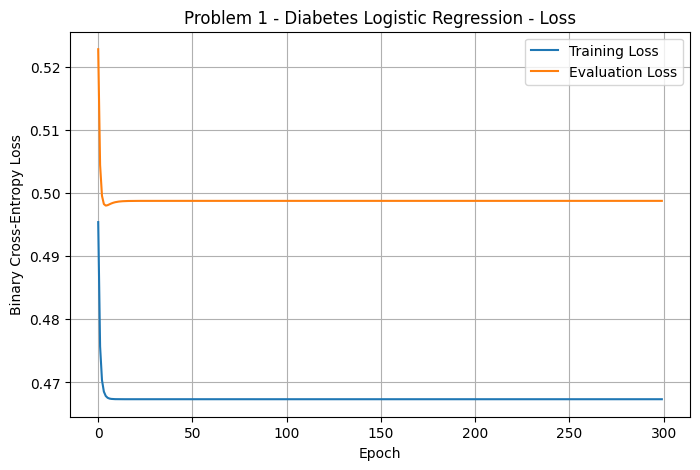

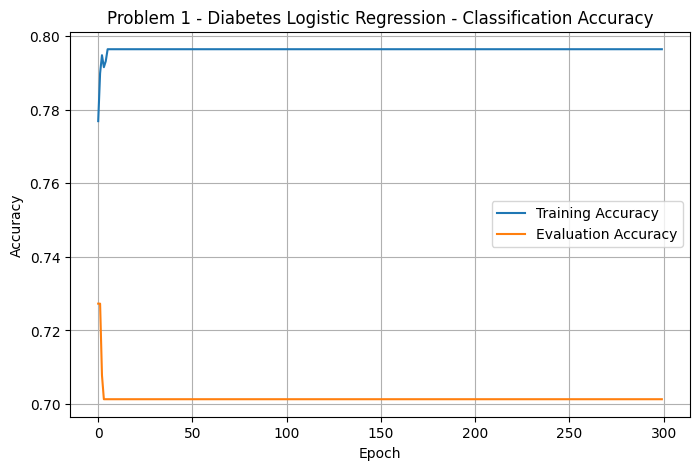

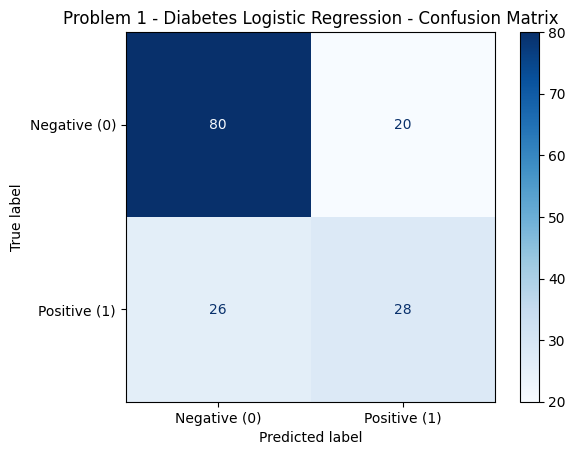

In [ ]:
model_d, results_d = train_model(
    X_train_d,
    X_test_d,
    y_train_d,
    y_test_d,
    title='Problem 1 - Diabetes Logistic Regression'
)

# Problem 2.1 - Cancer Logistic Regression (30 Features)|

In [ ]:
# Load cancer dataset
cancer = pd.read_csv('/content/Cancer.csv')

# Remove ID and empty column
cancer = cancer.drop(columns=['id', 'Unnamed: 32'])

# Encode diagnosis:
# Malignant = 1 (positive)
# Benign = 0 (negative)
cancer['diagnosis'] = cancer['diagnosis'].map({
    'M': 1,
    'B': 0
})

# Separate features and target
X_c = cancer.drop(columns=['diagnosis'])
y_c = cancer['diagnosis']

print("Dataset shape:", cancer.shape)
print("Number of input features:", X_c.shape[1])

# 80% training / 20% evaluation split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c,
    y_c,
    test_size=0.20,
    random_state=42,
    stratify=y_c
)

# Standardize the input features
scaler_c = StandardScaler()

X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)

print("Training samples:", len(y_train_c))
print("Evaluation samples:", len(y_test_c))

Dataset shape: (569, 31)
Number of input features: 30
Training samples: 455
Evaluation samples: 114



 Problem 2.1 - Cancer Without Regularization
---------------------------------------------
Accuracy: 0.9737
Precision: 0.9756
Recall: 0.9524
F1 Score: 0.9639
Final Training Loss: 0.0378
Final Evaluation Loss: 0.1294


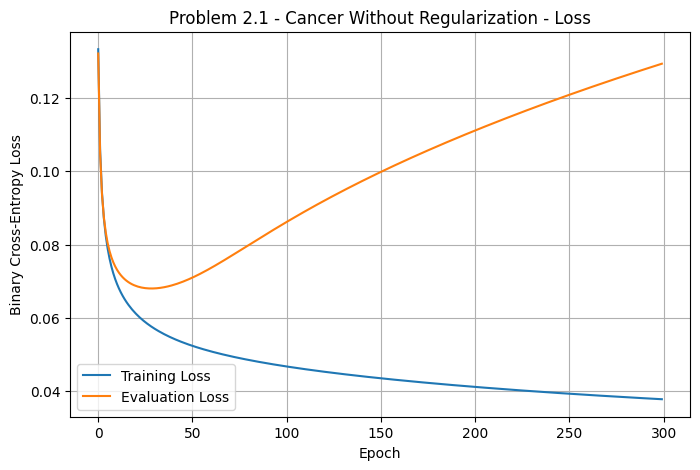

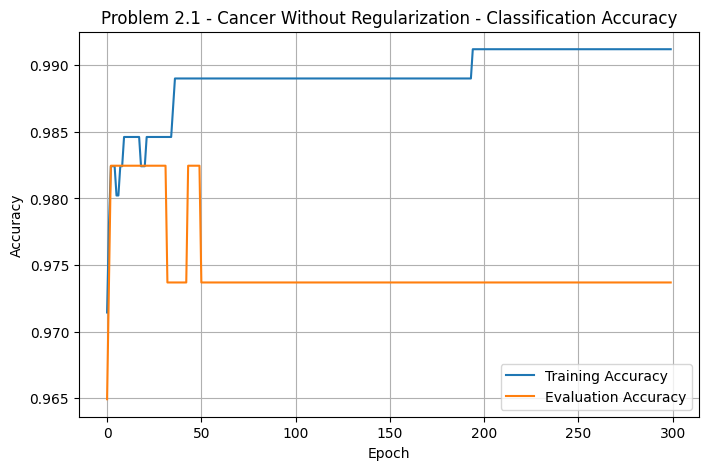

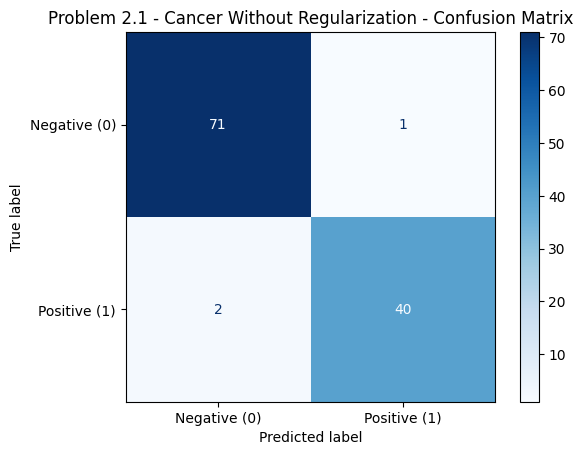

In [ ]:
model_c, results_c = train_model(
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c,
    title='Problem 2.1 - Cancer Without Regularization'
)

# Problem 2.2 - Cancer With L2 Weight Penalty


 Problem 2.2 - Cancer With L2 Regularization
---------------------------------------------
Accuracy: 0.9737
Precision: 0.9756
Recall: 0.9524
F1 Score: 0.9639
Final Training Loss: 0.0465
Final Evaluation Loss: 0.0877


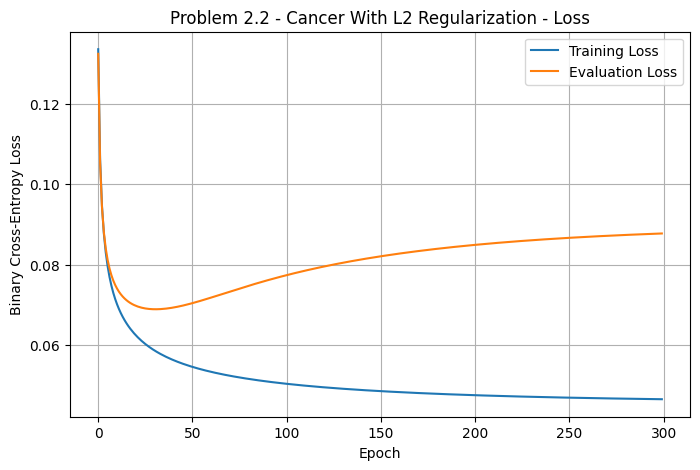

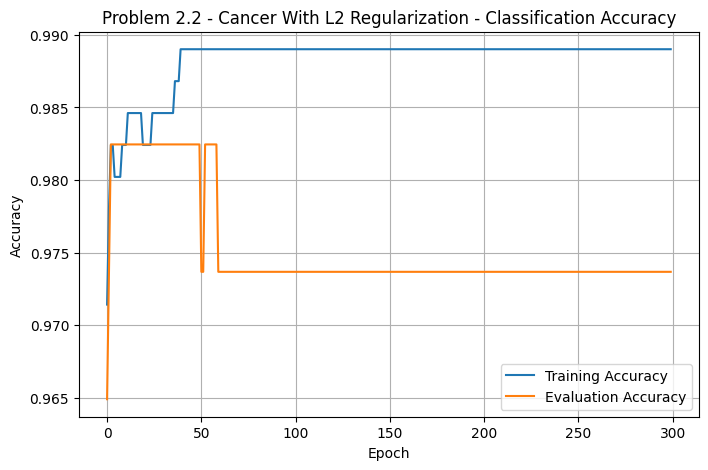

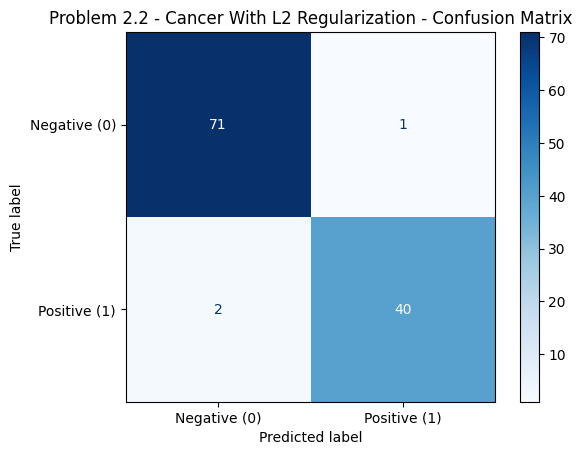

In [ ]:
model_c_reg, results_c_reg = train_model(
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c,
    title='Problem 2.2 - Cancer With L2 Regularization',
    penalty='l2',
    alpha=0.001
)

In [ ]:
comparison = pd.DataFrame({
    'Without Penalty': results_c,
    'With L2 Penalty': results_c_reg
})

print("Problem 2 - Cancer Model Comparison")

display(comparison.round(4))

print("\nModel Weight Magnitudes")

print(
    "Without Penalty:",
    np.linalg.norm(model_c.coef_)
)

print(
    "With L2 Penalty:",
    np.linalg.norm(model_c_reg.coef_)
)

Problem 2 - Cancer Model Comparison


,Without Penalty,With L2 Penalty
Accuracy,0.9737,0.9737
Precision,0.9756,0.9756
Recall,0.9524,0.9524
F1 Score,0.9639,0.9639



Model Weight Magnitudes
Without Penalty: 7.2715503712063
With L2 Penalty: 4.792053963182338


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Noah_Harris_801353171_HW3.ipynb to Noah_Harris_801353171_HW3 (1).ipynb


In [ ]:
import os
import subprocess

# Automatically find the uploaded notebook
notebooks = [
    f for f in uploaded.keys()
    if f.endswith('.ipynb')
]

notebook_name = notebooks[0]

# Convert to HTML, preserving graphs
subprocess.run([
    'jupyter',
    'nbconvert',
    '--to', 'html',
    '--embed-images',
    notebook_name
], check=True)

print("HTML conversion complete!")

HTML conversion complete!
